In [ ]:
# Tutorial
# https://nbviewer.org/github/OpenPIV/openpiv-python-examples/blob/main/notebooks/PIV_3D_example.ipynb
# GUI: https://pypi.org/project/openpivgui/

In [ ]:
from openpiv.pyprocess3D import *
from openpiv.PIV_3D_plotting import *
from openpiv.validation import sig2noise_val
from openpiv.filters import replace_outliers
from openpiv.lib import replace_nans
import glob as glob
import numpy as np
import os
from natsort import natsorted
import matplotlib.animation as animation

In [ ]:
# before_directory = 'data/data-PIV3D-1/BEFORE.tif.frames/'
# after_directory  = 'data/data-PIV3D-1/AFTER .tif.frames/'

before_directory = 'data/data-PIV3D-2/before.tif.frames/'
after_directory  = 'data/data-PIV3D-2/after.tif.frames/'

In [ ]:

# Convert from RGB to grayscale
def RGB_TO_GRAY(image):
    return np.dot(image[..., :3], [1/3, 1/3, 1/3])

In [ ]:
# Load image stacks
before_images = natsorted(glob.glob(os.path.join(before_directory, "before_C001Z*.tif")))
after_images  = natsorted(glob.glob(os.path.join(after_directory, "after_C001Z*.tif")))

before_sample = RGB_TO_GRAY(plt.imread(before_images[0]))
after_sample  = RGB_TO_GRAY(plt.imread(after_images[0]))

image_shape = before_sample.shape

# Display a before and after slice
plt.imshow(np.hstack([before_sample, after_sample]), cmap = plt.get_cmap('gray'))

In [20]:

# Load images into 3D stack array
before_array = np.zeros((image_shape[0], image_shape[1], len(before_images)))
after_array  = np.zeros((image_shape[0], image_shape[1], len(after_images)))

for i, image in enumerate(before_images):
	before_array[:, :, i] = RGB_TO_GRAY(plt.imread(image))

for i, image in enumerate(after_images):
	after_array[:, :, i] = RGB_TO_GRAY(plt.imread(image))

before_array.shape

(1200, 1600, 35)

In [21]:
x_dim = 32
y_dim = 32
z_dim = 6

win_overlap = 0.5

window_size = (x_dim, y_dim, z_dim)
overlap = (int(x_dim * win_overlap), int(y_dim * win_overlap), int(z_dim * win_overlap))
search_area = (x_dim, y_dim, z_dim)

In [9]:
# Calculate 3D Particle Image Velocimetry
# https://openpiv.readthedocs.io/en/latest/src/openpiv.html

u, v, w, sig2noise = extended_search_area_piv3D(
	before_array, after_array, 
	window_size = window_size, 
	overlap = overlap,
	search_area_size = search_area, 
	subpixel_method = 'gaussian',
	sig2noise_method = 'peak2peak',
	width = 2
)

100%|██████████| 74/74 [13:15<00:00, 10.75s/it]


In [10]:
# Clearing memory
before_array = None
after_array = None

In [11]:
# Correcting stage drift between the field of views
u -= np.nanmean(u)
v -= np.nanmean(v)
w -= np.nanmean(w)

In [80]:
u.shape

(74, 99, 10)

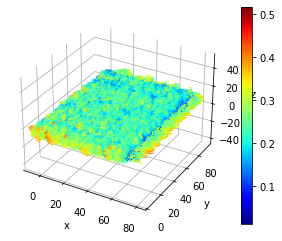

In [65]:
fig1 = quiver_3D(-u, v, w, filter_reg = 1, quiv_args={"length": 0.05, "alpha": 0.8, "linewidth": 0.5}) #, filter_def=0.1)

# https://dawes.wordpress.com/2014/06/27/publication-ready-3d-figures-from-matplotlib/
# Make background white
ax = plt.gca()
# ax.grid(False)
ax.w_xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.w_yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
ax.w_zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

plt.savefig(f'results/Quiver_Displacement_{x_dim}x{y_dim}x{z_dim}_dpi600_downsample1.png', dpi = 600)

In [32]:
# Calculate strain from displacement
U = u
V = v
W = w

# Calculate displacement gradients
dUdx, dUdy, dUdz = np.gradient(U)
dVdx, dVdy, dVdz = np.gradient(V)
dWdx, dWdy, dWdz = np.gradient(W)

# Compute strain tensor components
Exx = dUdx  # Strain in x
Eyy = dVdy  # Strain in y
Ezz = dWdz  # Strain in z
Exy = 0.5 * (dUdy + dVdx)  # Shear strain xy
Eyz = 0.5 * (dVdz + dWdy)  # Shear strain yz
Exz = 0.5 * (dUdz + dWdx)  # Shear strain xz

# Create a list of strain tensors for each point in space
shape = U.shape
Strain = np.empty(shape + (3, 3))

for i in range(shape[0]):
    for j in range(shape[1]):
        for k in range(shape[2]):
            Strain[i, j, k] = np.array([[Exx[i, j, k], Exy[i, j, k], Exz[i, j, k]],
                                        [Exy[i, j, k], Eyy[i, j, k], Eyz[i, j, k]],
                                        [Exz[i, j, k], Eyz[i, j, k], Ezz[i, j, k]]])

# 'Strain' now contains the strain tensors for each point in space


In [71]:
Exx.shape

(74, 99, 10)

In [93]:
# Define material parameters
C01 = -1360
C10 = 1940

# Define deformation gradient tensor F
Fx, Fy, Fz = Exx, Eyy, Ezz
for i in range(Exx.shape[2]):
	Fx[i, i, i] += 1
	Fy[i, i, i] += 1
	Fz[i, i, i] += 1

# Elastic models
# Neo-Hookean solid
# mooney rivlin


def mooney_rivlin(F):

	# Calculate the right Cauchy-Green deformation tensor C
	# C = np.dot(F.T, F)

	# Calculate the left Cauchy-Green deformation tensor B
	# B = np.dot(F, F.T)

	# Left cauchy-green tensor
	# B_ij = np.einsum('...ki,...kj->...ij', deformation_tensor, deformation_tensor)

	# Right cauchy-green tensor
	C_ij = np.einsum('...ik,...jk->...ij', deformation_tensor, deformation_tensor)
	print(C_ij.shape)

	# Calculate the invariants I1 and I2
	I1 = np.trace(C_ij, axis1=-2, axis2=-1)
	I2 = 0.5 * (np.trace(C_ij, axis1=-2, axis2=-1)**2 - np.trace(np.einsum('...ij,...jk->...ik', C_ij, C_ij), axis1=-2, axis2=-1))

	# Calculate the invariants of C
	I1 = np.trace(C)
	I2 = 0.5 * (np.trace(C)**2 - np.trace(np.dot(C, C)))

	W = C10 * (I1 - 3) + C01 * (I2 - 3)

	# Calculate the 2nd Piola-Kirchhoff stress tensor S
	# S = 2 * (np.gradient(W)) / (np.gradient(C_ij))

	return S


Sx = mooney_rivlin(Fx)

print("Stress Tensor Sx:\n", Sx)

def traction_vector_from_piola_kirchoff(F, S):

	# Define the normal to the surface in the reference configuration
	n = np.array([0.0, 0.0, 1.0]) 

	# Calculate the determinant of F
	J = np.linalg.det(F)

	# Calculate the traction vector t
	t = J * np.dot(np.dot(F, S.T), n)

t = traction_vector_from_piola_kirchoff(Fx, Sx)

#print("Traction Vector t:", t)


(74, 99, 99)


ValueError: shapes (74,99,10) and (74,99,10) not aligned: 10 (dim 2) != 99 (dim 1)

In [36]:
# Display strain magnitudes and directions

# fig2 = quiver_3D(E_xx, E_yy, E_zz, filter_reg = 1, quiv_args={"length": 0.05, "alpha": 0.8, "linewidth": 0.5})#, filter_def=0.1)
# plt.savefig('results/Quiver_Strain_dpi600_downsample1.png', dpi = 600)

(74, 204)
(74, 306)
(74, 408)
(74, 510)
(74, 612)
(74, 714)
(74, 816)
(74, 918)
(74, 1020)
AVERAGE_TRACTION_FORCE_OVERALL:  58.675305269957235


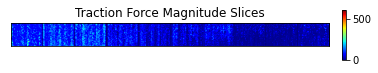

In [37]:

E = 2500    # Young's modulus
nu = 0.495  # Poisson's ratio

def compute_stress(strain_tensor, E, nu):
    # Compute the trace of the strain tensor
    trace_strain = np.trace(strain_tensor)
   
    # Compute stress tensor for simple elastic material model in 3D
    stress_tensor = np.zeros((3,3))
    for i in range(3):
        for j in range(3):
            stress_tensor[i][j] = E * strain_tensor[i][j] / (1 + nu) + (nu * trace_strain) / ((1 + nu) * (1 - 2*nu)) * (1 if i==j else 0)
           
    return stress_tensor

def compute_traction(stress_tensor, normal_vector):
    
	# Compute the traction force on a specific surface
    return np.dot(stress_tensor, normal_vector)

shape = Strain[..., 0, 0].shape

normal_vector_z = np.array([0, 0, 1])  # z-axis (THE ACTUAL NORMAL VECTOR)

pad = 3
col = 0
TRACTION_MAP = np.zeros((shape[0], shape[1] * shape[2] + pad * shape[2]))

grid = None
for k in range(shape[2]):
	temp = np.zeros((shape[0], shape[1] + pad))
	for i in range(shape[0]):
		for j in range(shape[1]):
		
			strain_tensor = Strain[i, j, k]
			stress_tensor = compute_stress(strain_tensor, E, nu)
			traction_force_z = compute_traction(stress_tensor, normal_vector_z)

			traction_magnitude_z = np.sqrt(np.sum(traction_force_z ** 2))

			temp[i, j] = traction_magnitude_z
		
	if grid is None:
		grid = temp
		continue
	else:
		grid = np.hstack([grid, temp])
	print(grid.shape)

TRACTION_MAP = grid

figure = plt.imshow(TRACTION_MAP, cmap = plt.get_cmap('jet'))
figure.axes.get_xaxis().set_visible(0)
figure.axes.get_yaxis().set_visible(0)
plt.title("Traction Force Magnitude Slices")
plt.colorbar(fraction = 0.01, aspect = 15, pad = 0.04)
plt.savefig('results/Slices_Traction_Magnitude_dpi600.png', dpi = 600)

average_traction_force_overall = np.mean(TRACTION_MAP)
print('AVERAGE_TRACTION_FORCE_OVERALL: ', average_traction_force_overall)

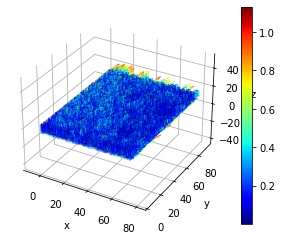

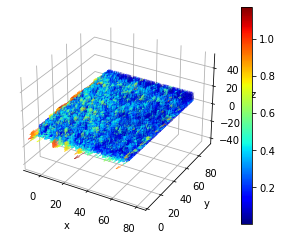

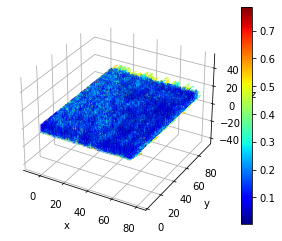

In [38]:
# Calculate the First, Third, Shear Strains

first_principal_strain = np.empty(shape)
third_principal_strain = np.empty(shape)
shear_strain           = np.empty(shape)

first_strain_vec = np.empty(shape + (3,))
third_strain_vec = np.empty(shape + (3,))
shear_strain_vec = np.empty(shape + (3,))

for i in range(shape[0]):
	for j in range(shape[1]):
		for k in range(shape[2]):

			eigenvalues, _ = np.linalg.eigh(Strain[i, j, k])

			# MAGNITUDE MAPS
			first_principal_strain[i, j, k] = np.sqrt(np.sum(eigenvalues[2] ** 2))
			third_principal_strain[i, j, k] = np.sqrt(np.sum(eigenvalues[0] ** 2))
			shear_strain[i, j, k] = np.sqrt(np.sum(
				(0.5 * (first_principal_strain[i, j, k] - third_principal_strain[i, j, k])) ** 2))

			# VECTOR MAPS
			first_strain_vec[i, j, k] = eigenvalues[2]
			third_strain_vec[i, j, k] = eigenvalues[0]
			shear_strain_vec[i, j, k] = 0.5 * (first_strain_vec[i, j, k] - third_strain_vec[i, j, k])

# Display strain magnitudes and directions

all_strains = [first_strain_vec, third_strain_vec, shear_strain_vec]
STRAIN_NAMES = ['First', 'Third', 'Shear']

for i, st in enumerate(all_strains):

	NAME = STRAIN_NAMES[i]+ ('' if STRAIN_NAMES[i] == 'Shear' else ' Principal')

	a = st[..., 0]
	b = st[..., 1]
	c = st[..., 2]

	fig2 = quiver_3D(a, b, c, filter_reg = 1, quiv_args={"length": 0.05, "alpha": 0.8, "linewidth": 0.5})#, filter_def=0.1)
	
	# Make background white
	ax = plt.gca()
	# ax.grid(False)
	ax.w_xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
	ax.w_yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
	ax.w_zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
	
	plt.savefig(f'results/Quiver_Strain_{NAME.replace(" ", "_")}_dpi600_downsample1.png', dpi = 600)

              

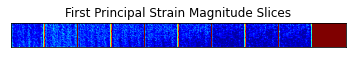

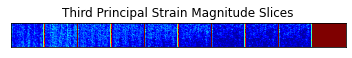

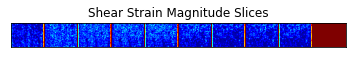

In [40]:
# Plot the above ^^^

# 2D heatmaps of intensity of strain on each type of strain

pad = 2
SCALE = 1

STRAIN_NAMES = ['First', 'Third', 'Shear']
STRAINS = [first_principal_strain, third_principal_strain, shear_strain]

for i in range(3):

	NAME = STRAIN_NAMES[i]+ ('' if STRAIN_NAMES[i] == 'Shear' else ' Principal')
	MAP = STRAINS[i]

	# Long panel of pixels, padded between panels
	blocks = np.ones((MAP.shape[0], MAP.shape[1] * MAP.shape[2] + pad * MAP.shape[2]))

	blocks = np.kron(blocks, np.ones((SCALE, SCALE)))

	grid = np.kron(MAP[:, :, 0], np.ones((SCALE, SCALE)))

	row = 0
	col = 0

	for i in range(1, MAP.shape[2]):
		layer = np.kron(MAP[:, :, i], np.ones((SCALE, SCALE)))

		blocks[row : row + layer.shape[0], col : col + layer.shape[1]] = layer
		col += layer.shape[1] + pad
		grid = np.hstack([grid, layer])

	figure = plt.imshow(blocks, cmap = plt.get_cmap('jet'), vmin = layer.min(), vmax = layer.max())
	figure.axes.get_xaxis().set_visible(0)
	figure.axes.get_yaxis().set_visible(0)
	plt.title("FIRST PRINCIPAL STRAIN INTENSITY MAP")
	plt.title(f"{NAME} Strain Magnitude Slices")
	plt.savefig(f'results/Slices_Strain_{NAME.replace(" ", "_")}_Magnitudes_dpi600.png', dpi = 600)
	plt.show()